# Batch AND-OR solving

In [9]:
import sys
sys.path.append("../scripts")
import os
import shutil

import and_or as ao
import lib


In [10]:
INPUT_PATH = "../data/rush_nw_training.txt"
OUTPUT_DIR = "../solve_attempts_hint"
MAX_STEPS = 200
GAMMA = 0.2  # AND-OR lapse probability (0 never lapses)
N_PUZZLES = 10  # first N puzzles of INPUT_PATH to solve and render
N_RUNS = 12  # solve attempts per puzzle, to see how consistently one car is critical
HORIZON_GAMMA = GAMMA  # the observer's gamma (known or estimated) setting the reasoning horizon
BUDGET = ao.or_budget(HORIZON_GAMMA)  # OR nodes a pass gets through without lapsing at least half the time
N_SIM = 1000  # solve attempts per condition in the hinting experiment
FORECAST_MOVES = 20  # how many moves ahead the observer forecasts the critical point
FORECAST_ROLLOUTS = 10  # simulated continuations per forecast


In [11]:
puzzles = lib.read_puzzles(INPUT_PATH)
sum(len(states) for states in puzzles.values())


100

In [12]:
def solve_puzzle(state, max_steps=MAX_STEPS, gamma=GAMMA, hint=None):
    """AND-OR passes from `state` until one reaches the exit (returns every
    move played) or the move budget runs out (None). `hint`, if given, is a
    hint(state, n_moves) -> move or None callable asked before each pass
    until it first returns a move, which is played as one extra move - the
    observer's single hint for this attempt."""
    moves = []
    while len(moves) < max_steps:
        if hint is not None:
            move = hint(state, len(moves))
            if move is not None:
                state = ao.AndNode(state, *move).apply(state)
                moves.append(move)
                hint = None
                continue
        attempt = ao.solve(state, gamma=gamma)
        if type(attempt) is list:
            moves.extend(attempt)
            return moves
        state, step_moves = attempt
        if not step_moves:
            return None
        moves.extend(step_moves)
    return None

## Estimate the final-pass boundary and critical car

- **Boundary** (`ao.final_pass_start`): recovered from the move list alone - the earliest point after which every remaining move could have been one lapse-free plan. It never lands after the true start, but can land a few moves before it when the last lapse moves happen to fit the final plan. Marked as a red line on each `trajectory.png`.
- **Reasoning horizon** (`ao.or_budget`): `BUDGET` OR nodes, the most a pass gets through without lapsing at least half the time at `HORIZON_GAMMA` (the true `GAMMA` for now; an estimate for observed data).
- **Car outside the horizon** (`ao.horizon_car`): in each frame, the car one past `BUDGET` on the shortest chain of subgoals from red down to a first move (`ao.first_path`) - the first subgoal a pass can't reason back to. Only that chain has to fit, not the whole plan, since a completed branch is played out even if the pass lapses later. Outlined in blue in the move PNGs and video; no car is outlined while the chain fits within the horizon, or while red itself must move first (no single pass can plan that).
- **Critical car** (`lib.critical_car`): the last car outside the horizon before the final pass. It belongs to one attempt, not the puzzle, so each car is filled from gray to blue - and labeled with a percentage - by the share of all `N_RUNS` attempts that picked it (attempts that failed or had no critical car count toward the total but mark no car); `result.txt` has the raw counts.

In [13]:
from collections import Counter

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

selected = [(dist, idx, state) for dist in sorted(puzzles) for idx, state in enumerate(puzzles[dist])][:N_PUZZLES]
critical_shares = {}  # (dist, idx) -> {car: share of N_RUNS attempts that found it critical}
mean_moves = {}  # (dist, idx) -> mean moves over N_RUNS attempts, failures counted as MAX_STEPS
solved_count = 0
for total, (dist, idx, state) in enumerate(selected, start=1):
    runs = [solve_puzzle(state) for _ in range(N_RUNS)]
    solved_runs = [run for run in runs if run is not None]
    counts = Counter(lib.critical_car(state, run, BUDGET) for run in solved_runs)
    shading = {car: n / N_RUNS for car, n in counts.items() if car is not None}
    critical_shares[(dist, idx)] = shading
    mean_moves[(dist, idx)] = sum(len(run) if run is not None else MAX_STEPS for run in runs) / N_RUNS
    moves = solved_runs[0] if solved_runs else None
    boundary = ao.final_pass_start(state, moves) if moves is not None else None
    critical = lib.critical_car(state, moves, BUDGET)
    folder = os.path.join(OUTPUT_DIR, f"dist_{dist:03d}_puzzle_{idx:03d}")
    lib.visualize(folder, state, moves, boundary=boundary,
                  highlight=lambda s: ao.horizon_car(s, BUDGET), shading=shading)
    with open(os.path.join(folder, "result.txt"), "w") as f:
        if moves is not None:
            solved_count += 1
            f.write(f"SOLVED in {len(moves)} moves\n")
            f.write(f"final pass starts at move {boundary}\n")
            f.write(f"critical car {critical} (horizon {BUDGET} OR nodes)\n")
        else:
            f.write("FAILED to solve\n")
        f.write(f"critical car across {len(solved_runs)}/{N_RUNS} solved attempts: {dict(counts.most_common())}\n")
        f.write(f"mean moves across {N_RUNS} attempts: {mean_moves[(dist, idx)]:.1f}\n")
    status = (f"solved ({len(moves)} moves, final pass from move {boundary}, critical car {critical})"
              if moves is not None else "FAILED")
    print(f"[{total}] dist={dist} puzzle={idx}: {status}; across attempts {dict(counts.most_common())},"
          f" mean moves {mean_moves[(dist, idx)]:.1f}")

print(f"\n{solved_count}/{len(selected)} puzzles solved")

[1] dist=10 puzzle=0: solved (19 moves, final pass from move 17, critical car None); across attempts {None: 12}, mean moves 16.4
[2] dist=10 puzzle=1: solved (52 moves, final pass from move 44, critical car K); across attempts {'K': 11}, mean moves 75.2
[3] dist=10 puzzle=2: solved (21 moves, final pass from move 15, critical car F); across attempts {'F': 10, 'E': 2}, mean moves 35.9
[4] dist=10 puzzle=3: solved (90 moves, final pass from move 84, critical car None); across attempts {None: 7, 'D': 4}, mean moves 90.7
[5] dist=10 puzzle=4: solved (51 moves, final pass from move 45, critical car E); across attempts {'E': 12}, mean moves 35.8
[6] dist=10 puzzle=5: solved (102 moves, final pass from move 98, critical car None); across attempts {None: 12}, mean moves 39.1
[7] dist=10 puzzle=6: solved (23 moves, final pass from move 17, critical car C); across attempts {'C': 10, None: 2}, mean moves 33.2
[8] dist=10 puzzle=7: solved (48 moves, final pass from move 45, critical car None); acr

## Hinting experiment

On the puzzle with the clearest critical car (the highest single-car share above, then its lead over the runner-up, then the most mean moves across the `N_RUNS` attempts - harder puzzles leave hints more room to show a difference), an observer that knows every state's distance to goal (BFS) gets to play **one move per attempt** (`lib.hint_move`): the move that starts the reasoning chain the model can't get down on its own (`ao.chain_first_moves`) - the deepest subgoal's resolving move, which unblocks the car above it. When several plans start with different moves, it picks the one closest to the goal. The base model plays every other move as usual. `N_SIM` attempts per condition:

- **unassisted** - no hint.
- **random-time hint** - the same kind of hint at a random pass start, drawn uniformly over the unassisted attempts' median length (an attempt that finishes first gets no hint).
- **critical-point hint** - the same kind of hint, timed by forecasting the **critical point**: the last board before the final pass where a critical car is outside the reasoning horizon - where the attempt is stuck on the critical chain for the last time. At each pass start the observer simulates the model `FORECAST_ROLLOUTS` times up to `FORECAST_MOVES` moves ahead, finds each continuation's critical point `k` moves away (none if it doesn't finish within the window), and hints with probability equal to the average of `max(0, 1 - k / FORECAST_MOVES)` - certain when the critical point is now, fading to zero `FORECAST_MOVES` moves out.

In [14]:
import random
import statistics


def selection_key(key):
    """(top car's share, its lead over the runner-up, mean moves) - clearest
    critical car first, then the harder puzzle, where hints have more room to
    show a difference."""
    top = sorted(critical_shares[key].values(), reverse=True) + [0, 0]
    return top[0], top[0] - top[1], mean_moves[key]


hint_key = max(critical_shares, key=selection_key)
hint_state = dict(((dist, idx), state) for dist, idx, state in selected)[hint_key]
hint_weights = critical_shares[hint_key]
distances = lib.multi_bfs(hint_state)
print(f"puzzle dist={hint_key[0]} idx={hint_key[1]}, critical shares {hint_weights},"
      f" mean moves {mean_moves[hint_key]:.1f}\n")


def moves_to_critical_point(state, window=FORECAST_MOVES):
    """Simulates the model once from `state`, up to `window` moves: how many
    moves until its critical point - the last board before its final pass
    with a critical car outside the horizon (0 = now). None if it doesn't
    finish within the window, or never faces a critical car again."""
    current, moves = state, []
    while len(moves) < window:
        attempt = ao.solve(current, gamma=GAMMA)
        if type(attempt) is list:
            boards = [state]
            for move in moves:
                boards.append(ao.AndNode(boards[-1], *move).apply(boards[-1]))
            return next((k for k in range(len(boards) - 1, -1, -1)
                         if ao.horizon_car(boards[k], BUDGET) in hint_weights), None)
        current, step_moves = attempt
        if not step_moves:
            return None
        moves.extend(step_moves)
    return None


def critical_point_hint():
    def hint(state, n_moves):
        offsets = [moves_to_critical_point(state) for _ in range(FORECAST_ROLLOUTS)]
        chance = sum(max(0.0, 1 - k / FORECAST_MOVES) for k in offsets if k is not None) / FORECAST_ROLLOUTS
        if random.random() < chance:
            return lib.hint_move(state, distances)
    return hint


def random_time_hint(median_length):
    step = random.randrange(max(1, int(median_length)))

    def hint(state, n_moves):
        if n_moves >= step:
            return lib.hint_move(state, distances)
    return hint


def run_condition(make_hint):
    """N_SIM attempts on hint_state, each with a fresh hint from make_hint()
    (None for no hint). Returns (moves, hint) pairs, hint being
    (move index, move, distance before, distance after) or None."""
    results = []
    for _ in range(N_SIM):
        given = []
        base = make_hint()

        def hint(state, n_moves):
            move = base(state, n_moves)
            if move is not None:
                after = ao.AndNode(state, *move).apply(state)
                given.append((n_moves, move, distances[state], distances[after]))
            return move

        moves = solve_puzzle(hint_state, hint=hint if base else None)
        results.append((moves, given[0] if given else None))
    return results


def report(name, results):
    lengths = [len(moves) for moves, _ in results if moves is not None]
    hinted = [given for _, given in results if given]
    sem = statistics.stdev(lengths) / len(lengths) ** 0.5
    line = (f"{name:20s} solved {len(lengths) / len(results):4.0%}  moves mean {statistics.mean(lengths):5.1f} ± {sem:.1f}"
            f"  median {statistics.median(lengths):4.0f}  hinted {len(hinted) / len(results):4.0%}")
    if hinted:
        line += (f"  (at move {statistics.median(g[0] for g in hinted):.0f},"
                 f" distance {statistics.mean(g[2] for g in hinted):.1f} -> {statistics.mean(g[3] for g in hinted):.1f};"
                 f" cars {dict(Counter(g[1][0] for g in hinted))})")
    print(line)


random.seed(0)
conditions = {"unassisted": run_condition(lambda: None)}
median_length = statistics.median(len(moves) for moves, _ in conditions["unassisted"] if moves is not None)
conditions["random-time hint"] = run_condition(lambda: random_time_hint(median_length))
conditions["critical-point hint"] = run_condition(critical_point_hint)
for name, results in conditions.items():
    report(name, results)

puzzle dist=10 idx=4, critical shares {'E': 1.0}, mean moves 35.8

unassisted           solved 100%  moves mean  38.4 ± 0.8  median   31  hinted   0%
random-time hint     solved 100%  moves mean  32.9 ± 0.7  median   27  hinted  76%  (at move 18, distance 7.5 -> 6.5; cars {'G': 614, 'D': 44, 'B': 20, 'E': 41, 'F': 33, 'C': 6})
critical-point hint  solved 100%  moves mean  32.5 ± 0.7  median   25  hinted  94%  (at move 11, distance 7.5 -> 6.5; cars {'G': 659, 'D': 172, 'F': 77, 'E': 27, 'B': 9})


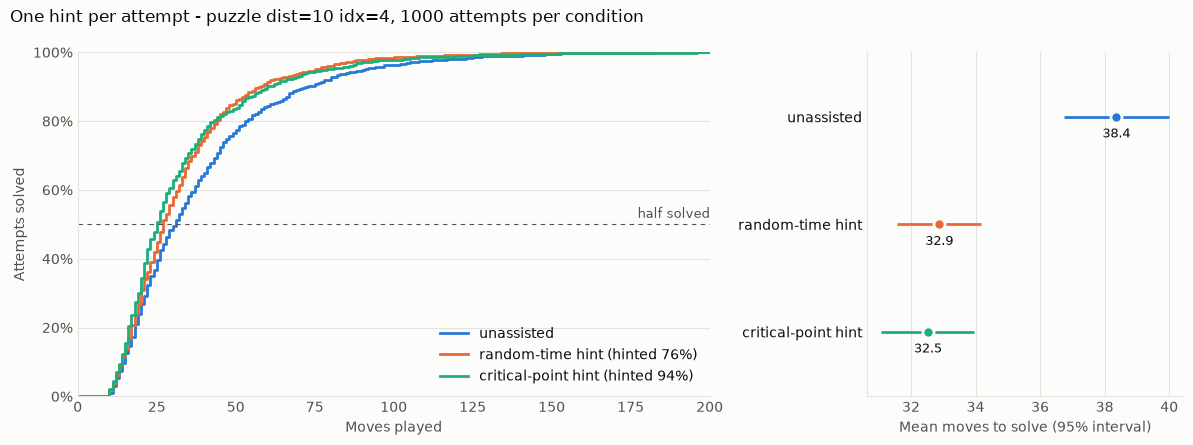

In [15]:
import bisect

import matplotlib.pyplot as plt

# Reference categorical slots 1-3 (validated as a set for colorblind separation).
COLORS = {"unassisted": "#2a78d6", "random-time hint": "#eb6834", "critical-point hint": "#1baf7a"}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

fig, (ax_cdf, ax_mean) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [2, 1]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax_cdf, ax_mean):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
    ax.set_axisbelow(True)

# Left: share of all N_SIM attempts solved within n moves.
xs = range(MAX_STEPS + 1)
for name, results in conditions.items():
    lengths = sorted(len(moves) for moves, _ in results if moves is not None)
    hinted = sum(given is not None for _, given in results) / len(results)
    label = name if name == "unassisted" else f"{name} (hinted {hinted:.0%})"
    ax_cdf.step(xs, [bisect.bisect_right(lengths, x) / len(results) for x in xs],
                where="post", color=COLORS[name], linewidth=2, label=label)
ax_cdf.axhline(0.5, color=INK_2, linewidth=0.8, linestyle=(0, (4, 4)))
ax_cdf.text(MAX_STEPS, 0.51, "half solved", color=INK_2, fontsize=9, ha="right", va="bottom")
ax_cdf.grid(axis="y", color=GRID, linewidth=0.8)
ax_cdf.set_xlim(0, MAX_STEPS)
ax_cdf.set_ylim(0, 1)
ax_cdf.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax_cdf.set_xlabel("Moves played", color=INK_2)
ax_cdf.set_ylabel("Attempts solved", color=INK_2)
ax_cdf.legend(loc="lower right", frameon=False, labelcolor=INK)

# Right: mean moves among solved attempts, with a 95% interval.
names = list(conditions)
for row, name in enumerate(names):
    lengths = [len(moves) for moves, _ in conditions[name] if moves is not None]
    mean = statistics.mean(lengths)
    half_width = 1.96 * statistics.stdev(lengths) / len(lengths) ** 0.5
    ax_mean.errorbar(mean, row, xerr=half_width, fmt="o", color=COLORS[name], markersize=8,
                     elinewidth=2, capsize=0, markeredgecolor=SURFACE, markeredgewidth=2)
    ax_mean.text(mean, row + 0.22, f"{mean:.1f}", color=INK, fontsize=9, ha="center", va="bottom")
ax_mean.set_yticks(range(len(names)), names, color=INK)
ax_mean.set_ylim(-0.6, len(names) - 0.4)
ax_mean.invert_yaxis()
ax_mean.grid(axis="x", color=GRID, linewidth=0.8)
ax_mean.set_xlabel("Mean moves to solve (95% interval)", color=INK_2)

fig.suptitle(f"One hint per attempt - puzzle dist={hint_key[0]} idx={hint_key[1]}, {N_SIM} attempts per condition",
             color=INK, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "hinting.png"), facecolor=SURFACE)
plt.show()

## Render videos

In [16]:
import subprocess

STEPS_PER_SECOND = 2


def make_video(folder, fps=STEPS_PER_SECOND):
    output_path = os.path.join(folder, "video.mp4")
    subprocess.run(
        [
            "ffmpeg", "-y",
            "-framerate", str(fps),
            "-i", os.path.join(folder, "move_%03d.png"),
            "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
            "-pix_fmt", "yuv420p",
            output_path,
        ],
        check=True, capture_output=True,
    )
    return output_path


for name in sorted(os.listdir(OUTPUT_DIR)):
    folder = os.path.join(OUTPUT_DIR, name)
    if os.path.isdir(folder):
        make_video(folder)
        print(f"wrote {os.path.join(folder, 'video.mp4')}")

wrote ../solve_attempts_hint/dist_010_puzzle_000/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_001/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_002/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_003/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_004/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_005/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_006/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_007/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_008/video.mp4
wrote ../solve_attempts_hint/dist_010_puzzle_009/video.mp4
